In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import auc


In [2]:
prob = "MountainCar"
window_size = 10
nb_episodes = 300


In [3]:
def compute_auc_and_std(data, nb_episodes):
    # data = np.load(filepath, allow_pickle=True)
    all_returns = data['episode_rewards']  # shape: (n_seeds, n_episodes)
    # print("all_returns ", all_returns, "\n")
    
    # print("all_returns shape:", all_returns.shape, "\n")
    aucs = []
    for rewards in all_returns:
        returns = rewards[:nb_episodes]
        x = np.arange(len(returns))
        aucs.append(auc(x, returns))

    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)
    return auc_mean, auc_std


In [4]:
base_path = f"C:\\Users\\nicle\\Desktop\\Master-thesis-clean-code\\Results\\{prob}"



## Plot subfigures



In [5]:
MC_dict_auc_mean = {}
MC_dict_auc_std = {}


QRNN-ASNN-PF-1Step: AUC = -59800.00 ± 0.00
QRNN-basic-PF-1Step: AUC = -59800.00 ± 0.00
QRNN-rnd-PF-1Step: AUC = -59800.00 ± 0.00
QRNN-RS-1Step: AUC = -59800.00 ± 0.00
50NN-ASNN-PF-1Step: AUC = -59800.00 ± 0.00
50NN-basic-PF-1Step: AUC = -59800.00 ± 0.00
50NN-rnd-PF-1Step: AUC = -59800.00 ± 0.00
50NN-RS-1Step: AUC = -59800.00 ± 0.00
MSENN-ASNN-PF-1Step: AUC = -59800.00 ± 0.00
MSENN-basic-PF-1Step: AUC = -59800.00 ± 0.00
MSENN-rnd-PF-1Step: AUC = -59800.00 ± 0.00
MSENN-RS-1Step: AUC = -59800.00 ± 0.00
QRNN-ASNN-PF-4Steps: AUC = -59799.33 ± 0.94
QRNN-basic-PF-4Steps: AUC = -59781.00 ± 19.61
QRNN-rnd-PF-4Steps: AUC = -59800.00 ± 0.00
QRNN-RS-4Steps: AUC = -59757.67 ± 25.00
50NN-ASNN-PF-4Steps: AUC = -59800.00 ± 0.00
50NN-basic-PF-4Steps: AUC = -59800.00 ± 0.00
50NN-rnd-PF-4Steps: AUC = -59762.33 ± 45.05
50NN-RS-4Steps: AUC = -59790.33 ± 8.18
MSENN-ASNN-PF-4Steps: AUC = -59357.17 ± 294.15
MSENN-basic-PF-4Steps: AUC = -59765.00 ± 25.15
MSENN-rnd-PF-4Steps: AUC = -59778.00 ± 31.11
MSENN-RS-4S

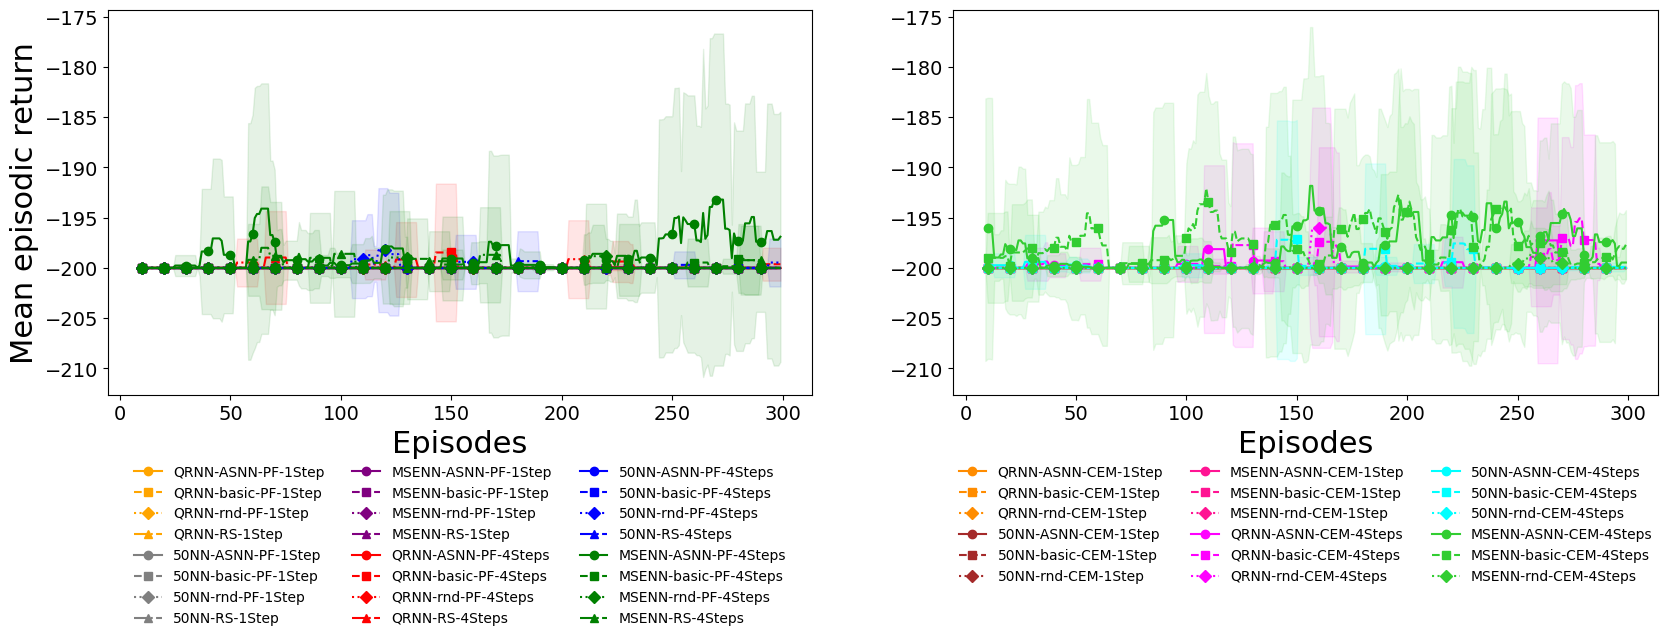

In [13]:
fig, axs = plt.subplots(1,2, figsize=(20, 5), sharey=True)

plt.rcParams.update({'font.size': 20})
for i, ax in enumerate(axs):
    # ax.plot([1, 2, 3], [j*(i+1) for j in [1, 4, 9]])
    # ax.set_title(f"Plot {i+1}", fontsize=20)
    ax.set_xlabel("Episodes", fontsize=22)
    ax.tick_params(axis='both', labelsize=14)
    ax.yaxis.set_tick_params(labelleft=True)

axs[0].set_ylabel("Mean episodic return", fontsize=22)

QRNN_OneStep = {
    'QRNN-ASNN-PF-1Step': f'{base_path}\\{prob}_MPC_QRNN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25.npz',
    'QRNN-basic-PF-1Step': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June25.npz',
    'QRNN-rnd-PF-1Step': f'{base_path}\\{prob}_MPC_QRNN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23.npz',
    'QRNN-RS-1Step': f'{base_path}\\{prob}_RS_mid_QRNN_ChangeHorizonTo30From70_AddedVelocity_June23.npz',}
color = 'orange'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_OneStep.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

############################################################################

FiftyNN_OneStep = {'50NN-ASNN-PF-1Step': f'{base_path}\\{prob}_MPC_50NN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25.npz',
    '50NN-basic-PF-1Step': f'{base_path}\\{prob}_MPC_50NN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June23.npz',
    '50NN-rnd-PF-1Step': f'{base_path}\\{prob}_MPC_50NN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23.npz',
    '50NN-RS-1Step': f'{base_path}\\{prob}_RS_mid_50NN_ChangeHorizonTo30From70_AddedVelocity_June23.npz',}
color = 'grey'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in FiftyNN_OneStep.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

############################################################################

MSENN_OneStep = {'MSENN-ASNN-PF-1Step': f'{base_path}\\{prob}_MPC_MSENN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25.npz',
    'MSENN-basic-PF-1Step': f'{base_path}\\{prob}_MPC_MSENN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June23.npz',
    'MSENN-rnd-PF-1Step': f'{base_path}\\{prob}_MPC_MSENN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23.npz',
    'MSENN-RS-1Step': f'{base_path}\\{prob}_RS_mid_MSENN_ChangeHorizonTo30From70_AddedVelocity_June23.npz'}
color = 'purple'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in MSENN_OneStep.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#############################################################

QRNN = {
    'QRNN-ASNN-PF-4Steps': f'{base_path}\\{prob}_MPC_QRNN_ASNN_mid_July31_4repeat.npz',
    'QRNN-basic-PF-4Steps': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_July31_4repeat.npz',
    'QRNN-rnd-PF-4Steps': f'{base_path}\\{prob}_MPC_QRNN_random_mid_July31_4repeat.npz',
    'QRNN-RS-4Steps': f'{base_path}\\{prob}_RS_mid_QRNN_July31_4repeat.npz',}
color = 'red'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

############################################################################

FiftyNN = {'50NN-ASNN-PF-4Steps': f'{base_path}\\{prob}_MPC_50NN_ASNN_mid_July31_4repeat.npz',
    '50NN-basic-PF-4Steps': f'{base_path}\\{prob}_MPC_50NN_basic_mid_July31_4repeat.npz',
    '50NN-rnd-PF-4Steps': f'{base_path}\\{prob}_MPC_50NN_random_mid_July31_4repeat.npz',
    '50NN-RS-4Steps': f'{base_path}\\{prob}_RS_mid_50NN_July31_4repeat.npz',}
color = 'blue'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in FiftyNN.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

############################################################################

MSENN = {'MSENN-ASNN-PF-4Steps': f'{base_path}\\{prob}_MPC_MSENN_ASNN_mid_July31_4repeat.npz',
    'MSENN-basic-PF-4Steps': f'{base_path}\\{prob}_MPC_MSENN_basic_mid_July31_4repeat.npz',
    'MSENN-rnd-PF-4Steps': f'{base_path}\\{prob}_MPC_MSENN_random_mid_July31_4repeat.npz',
    'MSENN-RS-4Steps': f'{base_path}\\{prob}_RS_mid_MSENN_July31_4repeat.npz'}
color = 'green'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in MSENN.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')



##############################################################


axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=False)

# from matplotlib.lines import Line2D

# custom_legend = [
#     Line2D([0], [0], color='red', lw=2, label='QRNN'),
#     Line2D([0], [0], color='blue', lw=2, label='50NN'),
#     Line2D([0], [0], color='green', lw=2, label='MSENN'),
#     Line2D([0], [0], color='black', marker='o', linestyle='None', markersize=6, label='ASGNN'),
#     Line2D([0], [0], color='black', marker='s', linestyle='None', markersize=6, label='QRNN-CEM'),
#     Line2D([0], [0], color='black', marker='^', linestyle='None', markersize=6, label='50NN-CEM')
# ]

# axs[0].legend(handles=custom_legend, loc='upper center', bbox_to_anchor=(0.5, -0.2),
#               ncol=3, fontsize=10, frameon=False)


###########################################################

print("############################################################# \n")

QRNN_CEM_1Step = {'QRNN-ASNN-CEM-1Step': f'{base_path}\\{prob}_MPC_QRNN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25_CEM.npz',
    'QRNN-basic-CEM-1Step': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',
    'QRNN-rnd-CEM-1Step': f'{base_path}\\{prob}_MPC_QRNN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',}
color = 'darkorange'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_CEM_1Step.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

########################################################

FiftyNN_CEM_1Step = {'50NN-ASNN-CEM-1Step': f'{base_path}\\{prob}_MPC_50NN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25_CEM.npz',
    '50NN-basic-CEM-1Step': f'{base_path}\\{prob}_MPC_50NN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',
    '50NN-rnd-CEM-1Step': f'{base_path}\\{prob}_MPC_50NN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',}
color = 'brown'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in FiftyNN_CEM_1Step.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


########################################################

MSENN_CEM_1Step = {'MSENN-ASNN-CEM-1Step': f'{base_path}\\{prob}_MPC_MSENN_ASGNN_mid_ChangeHorizonTo30From70_AddedVelocity_June25_CEM.npz',
    'MSENN-basic-CEM-1Step': f'{base_path}\\{prob}_MPC_MSENN_basic_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',
    'MSENN-rnd-CEM-1Step': f'{base_path}\\{prob}_MPC_MSENN_random_mid_ChangeHorizonTo30From70_AddedVelocity_June23_CEM.npz',}
color = 'deeppink'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in MSENN_CEM_1Step.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


########################################################
QRNN_CEM = {'QRNN-ASNN-CEM-4Steps': f'{base_path}\\{prob}_MPC_QRNN_ASNN_mid_July31_CEM_4repeat.npz',
    'QRNN-basic-CEM-4Steps': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_July31_CEM_4repeat.npz',
    'QRNN-rnd-CEM-4Steps': f'{base_path}\\{prob}_MPC_QRNN_random_mid_July31_CEM_4repeat.npz',}
color = 'magenta'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_CEM.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

########################################################

FiftyNN_CEM = {'50NN-ASNN-CEM-4Steps': f'{base_path}\\{prob}_MPC_50NN_ASNN_mid_July31_CEM_4repeat.npz',
    '50NN-basic-CEM-4Steps': f'{base_path}\\{prob}_MPC_50NN_basic_mid_July31_CEM_4repeat.npz',
    '50NN-rnd-CEM-4Steps': f'{base_path}\\{prob}_MPC_50NN_random_mid_July31_CEM_4repeat.npz',}
color = 'aqua'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in FiftyNN_CEM.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


########################################################

MSENN_CEM = {'MSENN-ASNN-CEM-4Steps': f'{base_path}\\{prob}_MPC_MSENN_ASNN_mid_July31_CEM_4repeat.npz',
    'MSENN-basic-CEM-4Steps': f'{base_path}\\{prob}_MPC_MSENN_basic_mid_July31_CEM_4repeat.npz',
    'MSENN-rnd-CEM-4Steps': f'{base_path}\\{prob}_MPC_MSENN_random_mid_July31_CEM_4repeat.npz',}
color = 'limegreen'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in MSENN_CEM.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
    MC_dict_auc_mean[label] = auc_mean
    MC_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


########################################################


axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=False)



# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left',ncol=2)
# axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=False)



In [17]:
sorted_dict = dict(sorted(MC_dict_auc_mean.items(), key=lambda item: item[1], reverse=True)[:6])
sorted_dict


{'QR-DQN': -47409.166666666664,
 'DQN': -55685.666666666664,
 'IV-DQN': -57488.5,
 'QRNN-ASNN-PF': -59800.0,
 'QRNN-basic-PF': -59800.0,
 'QRNN-rnd-PF': -59800.0}

In [18]:
MC_dict_auc_mean, MC_dict_auc_std


({'QRNN-ASNN-PF': -59800.0,
  'QRNN-basic-PF': -59800.0,
  'QRNN-rnd-PF': -59800.0,
  'QRNN-RS': -59800.0,
  '50NN-ASNN-PF': -59800.0,
  '50NN-basic-PF': -59800.0,
  '50NN-rnd-PF': -59800.0,
  '50NN-RS': -59800.0,
  'MSENN-ASNN-PF': -59800.0,
  'MSENN-basic-PF': -59800.0,
  'MSENN-rnd-PF': -59800.0,
  'MSENN-RS': -59800.0,
  'QRNN-ASNN-CEM': -59800.0,
  'QRNN-basic-CEM': -59800.0,
  'QRNN-rnd-CEM': -59800.0,
  '50NN-ASNN-CEM': -59800.0,
  '50NN-basic-CEM': -59800.0,
  '50NN-rnd-CEM': -59800.0,
  'MSENN-ASNN-CEM': -59800.0,
  'MSENN-basic-CEM': -59800.0,
  'MSENN-rnd-CEM': -59800.0,
  'DQN': -55685.666666666664,
  'IV-DQN': -57488.5,
  'QR-DQN': -47409.166666666664,
  'A2C': -59800.0,
  'PPO': -59800.0},
 {'QRNN-ASNN-PF': 0.0,
  'QRNN-basic-PF': 0.0,
  'QRNN-rnd-PF': 0.0,
  'QRNN-RS': 0.0,
  '50NN-ASNN-PF': 0.0,
  '50NN-basic-PF': 0.0,
  '50NN-rnd-PF': 0.0,
  '50NN-RS': 0.0,
  'MSENN-ASNN-PF': 0.0,
  'MSENN-basic-PF': 0.0,
  'MSENN-rnd-PF': 0.0,
  'MSENN-RS': 0.0,
  'QRNN-ASNN-CEM': 0.0

In [19]:
import json

# writing dictionary to a file as JSON
with open('C:\\Users\\nicle\\Desktop\\Master-thesis-clean-code\\AUC_data\\MC_auc_mean.json', 'w') as f:
    json.dump(MC_dict_auc_mean, f)

with open('C:\\Users\\nicle\\Desktop\\Master-thesis-clean-code\\AUC_data\\MC_auc_std.json', 'w') as f:
    json.dump(MC_dict_auc_std, f)


In [20]:
for key, value in MC_dict_auc_mean.items():
    print(f"{key}: {value:.2f} ± {MC_dict_auc_std[key]:.2f}")
    

QRNN-ASNN-PF: -59800.00 ± 0.00
QRNN-basic-PF: -59800.00 ± 0.00
QRNN-rnd-PF: -59800.00 ± 0.00
QRNN-RS: -59800.00 ± 0.00
50NN-ASNN-PF: -59800.00 ± 0.00
50NN-basic-PF: -59800.00 ± 0.00
50NN-rnd-PF: -59800.00 ± 0.00
50NN-RS: -59800.00 ± 0.00
MSENN-ASNN-PF: -59800.00 ± 0.00
MSENN-basic-PF: -59800.00 ± 0.00
MSENN-rnd-PF: -59800.00 ± 0.00
MSENN-RS: -59800.00 ± 0.00
QRNN-ASNN-CEM: -59800.00 ± 0.00
QRNN-basic-CEM: -59800.00 ± 0.00
QRNN-rnd-CEM: -59800.00 ± 0.00
50NN-ASNN-CEM: -59800.00 ± 0.00
50NN-basic-CEM: -59800.00 ± 0.00
50NN-rnd-CEM: -59800.00 ± 0.00
MSENN-ASNN-CEM: -59800.00 ± 0.00
MSENN-basic-CEM: -59800.00 ± 0.00
MSENN-rnd-CEM: -59800.00 ± 0.00
DQN: -55685.67 ± 1896.94
IV-DQN: -57488.50 ± 1268.37
QR-DQN: -47409.17 ± 3416.06
A2C: -59800.00 ± 0.00
PPO: -59800.00 ± 0.00
